# Step 1: Inventory Simulation Fundamentals (Summary)

## Why Inventory Simulation?
Inventory simulation models warehouse operations **day by day** because customer demand is uncertain. Instead of relying on formulas, it recreates daily events to evaluate inventory performance over time.

## Daily Warehouse Process
Each day follows the same sequence:

**Receive Deliveries → Customer Demand → Sell Available Inventory → Update Inventory → Check Inventory Policy → Place Order (if needed) → End Day**

> Every inventory policy uses this same simulation engine. Only the ordering decision changes.

## State Variables
The key values tracked during a simulation are:

- **Period (Day)** – Current simulation day.
- **Demand** – Customer request.
- **Sales** – Quantity actually sold (`min(inventory, demand)`).
- **Inventory** – Remaining stock after sales.
- **Orders Placed** – Purchase orders sent to suppliers.
- **Orders Received** – Deliveries received from suppliers.
- **Lost Sales** – Unmet demand due to insufficient inventory.

In [47]:
# Our first inventory simulation (no inventory)

import pandas as pd

demand = pd.Series([18,25,12,20,15])

print(demand)

0    18
1    25
2    12
3    20
4    15
dtype: int64


In [48]:
inventory = 100

records = []

for day, d in enumerate(demand, start = 1):
    
    sales = min(inventory, d)
    inventory -= sales
    
    records.append({
               'Day': day,
                'Demand': d,
                'Sales': sales,
                'Ending Inventory': inventory
    }
     )
    
df = pd.DataFrame(records)

print(df)



   Day  Demand  Sales  Ending Inventory
0    1      18     18                82
1    2      25     25                57
2    3      12     12                45
3    4      20     20                25
4    5      15     15                10


In [49]:
# when happens when demand exceeds inventory

inventory = 10

demand = 25

sales = min(inventory, demand)

inventory -= sales

lost_sales = demand - sales

print(sales)
print(lost_sales)
print(inventory)

10
15
0


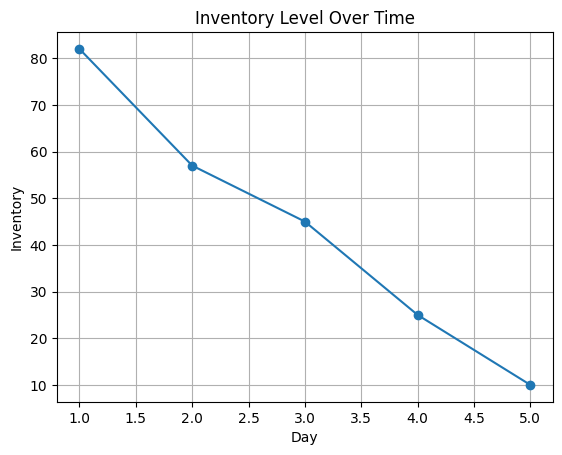

In [50]:
# Let's visualize the results

import matplotlib.pyplot as plt

plt.plot(df["Day"], df["Ending Inventory"], marker="o")

plt.xlabel("Day")
plt.ylabel("Inventory")
plt.title("Inventory Level Over Time")

plt.grid(True)

plt.show()

# Step 2: Continuous Review Policies (Summary)

## What is Continuous Review?
Inventory is **checked continuously (e.g., every day)**. Whenever inventory reaches a predefined level, a replenishment decision is made immediately.

## 1. (s, Q) Policy (Min-Q)
- **When to order:** Inventory ≤ **Reorder Point (s)**.
- **How much to order:** A **fixed quantity (Q)** every time.
- Order size never changes.

## 2. Base Stock Policy
- Inventory is reviewed continuously.
- After each review, order **just enough** to restore inventory to the **Base Stock Level**.
- Order quantity varies depending on current inventory.

## 3. (s, S) Policy (Min-Max)
- **When to order:** Inventory ≤ **Reorder Point (s)**.
- **How much to order:** Enough to raise inventory to the **Maximum Level (S)**.
- Order quantity changes based on inventory level.

## Lead Time
In practice, replenishment is **not immediate**. Orders arrive after a **lead time**, so inventory continues to decrease while waiting for delivery. (For simplicity, this step assumes immediate replenishment.)

## Policy Comparison

| Policy | When to Order | How Much to Order |
|---------|---------------|-------------------|
| **(s, Q)** | Inventory ≤ s | Fixed quantity (Q) |
| **Base Stock** | Every review | Enough to reach Base Stock level |
| **(s, S)** | Inventory ≤ s | Enough to reach Maximum level (S) |

## Key Takeaways
- Continuous review means inventory is monitored **continuously**, and replenishment decisions are made as soon as conditions are met.
- The **(s, Q)** policy uses a **fixed** order quantity.
- The **Base Stock** policy always restores inventory to a **target level**.
- The **(s, S)** policy orders **up to a maximum level** only when inventory falls below the reorder point.
- The main difference between these policies is **how much to order** once replenishment is triggered.

In [51]:
# Python Implementation of (s, Q) policy

import pandas as pd

demand = [25, 20, 35, 30, 40, 45, 25]

inventory = 200
reorder_point = 100
Q = 300

# empty list to store the records
records = []

for day, d in enumerate(demand, start = 0):
    
    # what we sell
    sales = min(inventory, d)
    inventory = inventory - sales
    
    order = 0
    # when to reorder
    if inventory < reorder_point:
        order = Q
        inventory += order
        
    records.append({
        'Day': day,
        'Demand': d,
        'Sales': sales,
        'Order': order,
        'Ending Inventory': inventory
    })

df = pd.DataFrame(records)

print(df)


   Day  Demand  Sales  Order  Ending Inventory
0    0      25     25      0               175
1    1      20     20      0               155
2    2      35     35      0               120
3    3      30     30    300               390
4    4      40     40      0               350
5    5      45     45      0               305
6    6      25     25      0               280


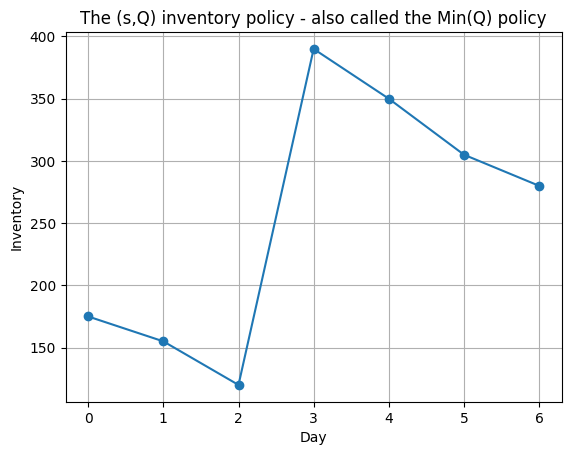

In [52]:
# To visualize (s,Q) policy
# Note now, we are having an assumption of instantaneous lead time here


import matplotlib.pyplot as plt

plt.plot(df["Day"], df["Ending Inventory"], marker="o")

plt.xlabel("Day")
plt.ylabel("Inventory")
plt.title("The (s,Q) inventory policy - also called the Min(Q) policy")

plt.grid(True)

plt.show()


In [53]:
# The Base Stock Policy

base_stock = 500 
inventory = 500

records = []
demand = [25, 20, 35, 30, 40, 45, 25]

for day, d in enumerate(demand, start = 1):
    sales = min(inventory, d)
    
    inventory -= sales
    
    order = base_stock - inventory
    
    inventory += order
    
    records.append({
            'Day': day,
            'Demand': d,
            'Sales': sales,
            'Order': order,
            'Ending Inventory': inventory
        })
    
df = pd.DataFrame(records)
    
print(df)
    
    

   Day  Demand  Sales  Order  Ending Inventory
0    1      25     25     25               500
1    2      20     20     20               500
2    3      35     35     35               500
3    4      30     30     30               500
4    5      40     40     40               500
5    6      45     45     45               500
6    7      25     25     25               500


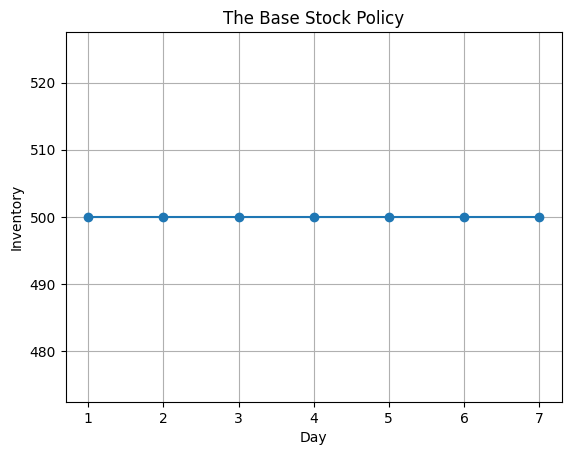

In [54]:
# To visualize Base Stock policy
# Note now, we are having an assumption of instantaneous lead time here


import matplotlib.pyplot as plt

plt.plot(df["Day"], df["Ending Inventory"], marker="o")

plt.xlabel("Day")
plt.ylabel("Inventory")
plt.title("The Base Stock Policy")

plt.grid(True)

plt.show()


In [55]:
# Min-Max Policy ((s, S))
s = 100 
S = 500

records = []
demand = [25, 210, 35, 300, 140, 45, 250, 300, 750, 307, 120]

for day, d in enumerate(demand, start = 1):
    sales = min(inventory, d)
    
    inventory -= sales
    
    if inventory <= s:
        
        order = S - inventory
        inventory += order
        
    else:
        order = 0
    
    records.append({
            'Day': day,
            'Demand': d,
            'Sales': sales,
            'Order': order,
            'Ending Inventory': inventory
        })
    
df = pd.DataFrame(records)
    
print(df)
    
    

    Day  Demand  Sales  Order  Ending Inventory
0     1      25     25      0               475
1     2     210    210      0               265
2     3      35     35      0               230
3     4     300    230    500               500
4     5     140    140      0               360
5     6      45     45      0               315
6     7     250    250    435               500
7     8     300    300      0               200
8     9     750    200    500               500
9    10     307    307      0               193
10   11     120    120    427               500


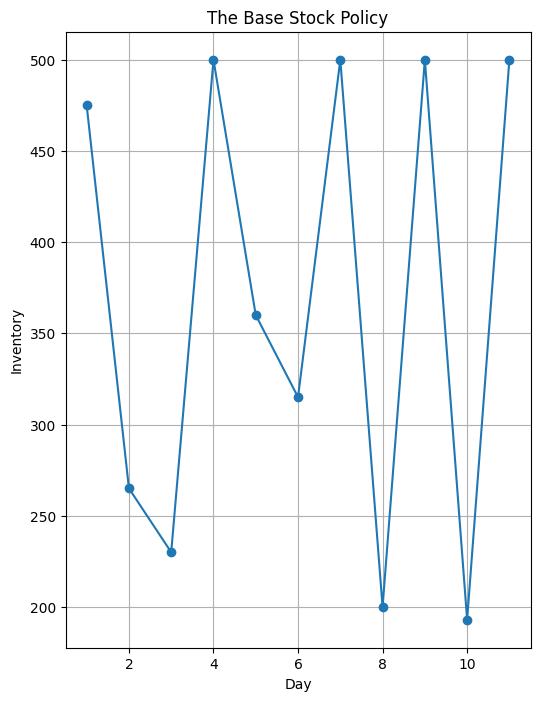

In [59]:
# To visualize Base Stock policy
# Note now, we are having an assumption of instantaneous lead time here


import matplotlib.pyplot as plt
plt.figure(figsize = (6,8))

plt.plot(df["Day"], df["Ending Inventory"], marker="o")

plt.xlabel("Day")
plt.ylabel("Inventory")
plt.title("The Base Stock Policy")

plt.grid(True)

plt.show()


# Step 3: Periodic Review Policies

## What is Periodic Review?
Inventory is **reviewed only at fixed time intervals (R)** (e.g., every 7 days), rather than continuously. Orders can only be placed on these scheduled review days.

## 1. (R, S) Policy
- **When to order:** Every **R** review periods.
- **How much to order:** Enough to restore inventory to the **Target Level (S)**.
- Inventory may become low before the next review because no orders are placed between review dates.

## 2. Hybrid Policy
- Combines **Periodic Review** with a **Minimum Inventory Level (s)**.
- **When to order:** Only if **(1)** it is a review day **and** **(2)** inventory is at or below **s**.
- **How much to order:** Enough to restore inventory to the **Target Level (S)**.

## Policy Comparison

| Policy | Review Style | Order Trigger | Order Quantity |
|---------|--------------|---------------|----------------|
| **(R, S)** | Periodic | Every R days | Restore to S |
| **Hybrid** | Periodic | Every R days **and** Inventory ≤ s | Restore to S |

## Key Takeaways
- **Continuous Review:** Inventory is monitored continuously, allowing immediate replenishment decisions.
- **Periodic Review:** Inventory is checked only on scheduled review days, reducing monitoring effort.
- The **(R, S)** policy orders at every review, while the **Hybrid** policy orders only when both the review schedule and minimum inventory condition are satisfied.

In [63]:
# Pytho Implementation of (R, S) policy

import pandas as pd

demand = [20, 30, 40, 25, 35, 20, 30]

inventory = 500

review_period = 3
target_level = 500

records = []

for day, d in enumerate(demand, start=1):

    # Customer demand
    sales = min(inventory, d)
    inventory -= sales

    order = 0

    # Review only every R days
    if day % review_period == 0:
        order = target_level - inventory
        inventory += order

    records.append({
        "Day": day,
        "Demand": d,
        "Order": order,
        "Ending Inventory": inventory
    })

df = pd.DataFrame(records)

print(df)


   Day  Demand  Order  Ending Inventory
0    1      20      0               480
1    2      30      0               450
2    3      40     90               500
3    4      25      0               475
4    5      35      0               440
5    6      20     80               500
6    7      30      0               470


In [66]:
# To implemeent the Hybrid Policy

import numpy as np

demand = np.random.randint(50,100, 11)

inventory = 500

review_period = 3

minimum = 200

target = 500

records = []

for day, d in enumerate(demand, start=1):

    sales = min(inventory, d)

    inventory -= sales

    order = 0

    if day % review_period == 0:

        if inventory <= minimum:

            order = target - inventory

            inventory += order

    records.append({
        "Day": day,
        "Inventory": inventory,
        "Order": order
    })

pd.DataFrame(records)


,Day,Inventory,Order
0,1,448,0
1,2,381,0
2,3,294,0
3,4,210,0
4,5,143,0
5,6,500,408
6,7,434,0
7,8,363,0
8,9,294,0
9,10,244,0


# Step 4: Evaluating Inventory Policies
## Why Evaluate Inventory Policies?
The goal is to determine **which policy performs best** by balancing **inventory costs** and **customer service**.

## Key Performance Metrics

| Metric | Purpose | Goal |
|--------|---------|------|
| **Holding Cost** | Cost of storing inventory | Minimize |
| **Ordering Cost** | Cost of placing purchase orders | Minimize |
| **Stockout Cost** | Cost of unmet demand | Minimize |
| **Total Cost** | Holding + Ordering + Stockout Costs | Minimize |
| **Fill Rate** | Percentage of demand satisfied | Maximize |
| **Cycle Service Level** | Probability of avoiding a stockout during a replenishment cycle | Maximize |

## Core Calculations
- **Holding Cost** = Average Inventory × Holding Cost per Unit
- **Ordering Cost** = Number of Orders × Cost per Order
- **Stockout Cost** = Lost Sales × Cost per Lost Unit
- **Total Cost** = Holding Cost + Ordering Cost + Stockout Cost
- **Fill Rate** = Total Sales ÷ Total Demand

## Comparing Policies
After simulating different policies, compare their **total costs** and **service levels** to identify the most suitable policy for the business objective (e.g., lowest cost or highest customer service).

## Key Takeaways
- No inventory policy is universally best; performance depends on business priorities.
- Inventory policies should be evaluated using **both cost and service metrics**.
- Simulation enables objective comparison by testing multiple policies under the same demand conditions.

In [ ]:
print('Hello World')

Hello World


In [69]:
# Average Inventory
inventory = [100,80,60,50,40]

average_inventory = sum(inventory)/len(inventory)

print(f'Avergae Inventory is {average_inventory}')

# if holding cost is #5 per unit

holding_cost = average_inventory * 5

print(f'The Holding cost is now: {holding_cost}')


Avergae Inventory is 66.0
The Holding cost is now: 330.0


In [ ]:
# Ordering Cost
orders = [300,0,0,300,0,300]

number_orders = sum(o > 0 for o in orders)

# if every order costs us #100

ordering_cost = number_orders * 100

print(f'The order cost is: {ordering_cost}')


The order cost is: 300


In [73]:
# Stockout (Shortage) Cost

lost_sales = 25 - 18

print(f'We have {lost_sales} lost sales')

# If every lost sales costs #20

stockout_cost = lost_sales * 20

print(f'The stockout cost for {lost_sales} lost sales is #{stockout_cost} per lost customer')


We have 7 lost sales
The stockout cost for 7 lost sales is #140 per lost customer


In [75]:
# Now to better understand the Totall Cost

holding = 330

ordering = 300

stockout = 140

total = holding + ordering + stockout

print(f'The total cost is #{total:.2f}')

The total cost is #770.00


In [77]:
# Now the metric fill rate
sales = [20,15,25,25]

demand = [20,15,30,25]

fill_rate = sum(sales)/sum(demand)
print(f'The fill rate is {round(fill_rate * 100, 2)}%')


The fill rate is 94.44%


In [80]:
# Now let's compare different inventory policies

import pandas as pd

results = pd.DataFrame({

    "Policy": [
        "Min-Q",
        "Base Stock",
        "Min-Max",
        "Periodic",
        "Hybrid"
    ],

    "Total Cost":[1220,1170,1230,1120,1160],

    "Fill Rate":[0.97,0.99,0.95,0.94,0.96]

})

print(results)

       Policy  Total Cost  Fill Rate
0       Min-Q        1220       0.97
1  Base Stock        1170       0.99
2     Min-Max        1230       0.95
3    Periodic        1120       0.94
4      Hybrid        1160       0.96


# Step 5: Building an Inventory Simulator

## Simulation Workflow
Every inventory simulator follows the same sequence:

**Initialize Inventory → Receive Deliveries → Observe Demand → Sell Inventory → Record Lost Sales → Apply Inventory Policy → Schedule Orders → Store Results → Repeat**

The **simulation engine remains the same**; only the **ordering decision** changes.

## Building the Simulator
1. Import required libraries.
2. Load or generate demand data.
3. Define inventory policy parameters.
4. Create a delivery schedule to account for lead time.
5. Simulate each day by:
   - Receiving deliveries.
   - Fulfilling demand.
   - Updating inventory.
   - Recording lost sales.
   - Applying the inventory policy.
   - Scheduling future deliveries.
6. Store daily results in a table.
7. Calculate performance metrics (Holding Cost, Ordering Cost, Stockout Cost, Fill Rate, Total Cost).
8. Summarize the simulation results for decision-making.

## Changing Inventory Policies
The simulation engine stays **unchanged**. Only the replenishment rule differs:

- **(s, Q):** If Inventory ≤ s, order **Q**.
- **Base Stock:** Order enough to restore the **Base Stock Level**.
- **(s, S):** If Inventory ≤ s, order enough to reach **S**.
- **(R, S):** On every review period **R**, order enough to reach **S**.
- **Hybrid:** On review period **R**, order only if Inventory ≤ s, then restore to **S**.

## Key Takeaways
- An inventory simulator is a **day-by-day event-driven model**.
- The same simulation framework can implement any inventory policy by changing only the **ordering rule**.
- The simulator produces **daily operational records** and **performance metrics**, enabling objective comparison of inventory policies.

In [81]:
# Import necessary libraries

import pandas as pd
import numpy as np

In [83]:
# Demand Data

np.random.seed(42)

demand = np.random.normal(
    loc=50,
    scale=10,
    size=30
).round().astype(int)

demand # this will be replaced by df['Sales'] in practice. The historical demand

array([55, 49, 56, 65, 48, 48, 66, 58, 45, 55, 45, 45, 52, 31, 33, 44, 40,
       53, 41, 36, 65, 48, 51, 36, 45, 51, 38, 54, 44, 47])

In [84]:
# We define policy parameters

inventory = 300

reorder_point = 100

order_quantity = 250

lead_time = 3

# and also create delivery schedule

deliveries = {}



In [85]:
# Let's simulate each day
records = []

for day, d in enumerate(demand, start=1):

    # Receive deliveries
    if day in deliveries:
        inventory += deliveries[day]

    # Sell inventory
    sales = min(inventory, d)

    lost_sales = d - sales

    inventory -= sales

    order = 0

    # Min-Q policy
    if inventory <= reorder_point:

        order = order_quantity

        arrival_day = day + lead_time

        deliveries[arrival_day] = (
            deliveries.get(arrival_day, 0)
            + order
        )

    records.append({
        "Day": day,
        "Demand": d,
        "Sales": sales,
        "Lost Sales": lost_sales,
        "Order Placed": order,
        "Inventory": inventory
    })


In [86]:
# Let's convert to a DataFrame

results = pd.DataFrame(records)

results.head()

,Day,Demand,Sales,Lost Sales,Order Placed,Inventory
0,1,55,55,0,0,245
1,2,49,49,0,0,196
2,3,56,56,0,0,140
3,4,65,65,0,250,75
4,5,48,48,0,250,27


In [87]:
# Let's evaluate performance

holding_cost = results["Inventory"].mean() * 5

ordering_cost = (
    (results["Order Placed"] > 0).sum()
    * 100
)

stockout_cost = (
    results["Lost Sales"].sum()
    * 20
)

fill_rate = (
    results["Sales"].sum()
    / results["Demand"].sum()
)

total_cost = (
    holding_cost
    + ordering_cost
    + stockout_cost
)

In [89]:
# Create Summary

summary = pd.DataFrame({

    "Metric":[
        "Holding Cost",
        "Ordering Cost",
        "Stockout Cost",
        "Fill Rate",
        "Total Cost"
    ],

    "Value":[
        holding_cost,
        ordering_cost,
        stockout_cost,
        fill_rate,
        total_cost
    ]

})
summary['Value'] = summary['Value'].round(2)
summary

,Metric,Value
0,Holding Cost,1430.33
1,Ordering Cost,600.00
2,Stockout Cost,1580.00
3,Fill Rate,0.95
4,Total Cost,3610.33


####  Now, you could make other policies using the thinking we used earlier.